# Causation, Collision, and Confusion

This notebook contains the text from Chapter 7 of *[Probably Overthinking It: How to Use Data to Answer Questions, Avoid Statistical Traps, and Make Better Decisions](https://greenteapress.com/wp/probably-overthinking-it)* (University of Chicago Press, 2023), along with the supporting code used in the analysis.

*Probably Overthinking It* is available from [Bookshop.org](https://bookshop.org/a/98697/9780226822587) and [Amazon](https://amzn.to/3Kp629E) (affiliate links).

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ProbablyOverthinkingIt/blob/book/notebooks/birthweight.ipynb).

In [1]:
# Install empiricaldist if we don't already have it

try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [2]:
# download utils.py

from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
        
download("https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/notebooks/utils.py")

In [3]:
import matplotlib.pyplot as plt
from utils import set_pyplot_params, decorate

set_pyplot_params()

In [4]:
import pandas as pd
import numpy as np

# Set the random seed so we get the same results every time
np.random.seed(17)

The Low Birthweight Paradox was born in 1971, when Jacob Yerushalmy, a researcher at U.C. Berkeley, published "The relationship of parents' cigarette smoking to outcome of pregnancy -- implications as to the problem of inferring causation from observed associations".
As the title suggests, the paper is about the relationship between smoking during pregnancy, the weight of babies at birth, and mortality in the first month of life.

Based on data from about 13,000 babies born near San Francisco between 1960 and 1967, Yerushalmy reported that

* Babies of mothers who smoked were about 6% lighter at birth. 

* Smokers were about twice as likely to have babies lighter than 2500 grams, which is considered "low birthweight".

* Low-birthweight babies were much more likely to die within a month of birth: the mortality rate was 174 per 1000 for low-birthweight babies and 7.8 per 1000 for others.

These results were not surprising. At that time, it was well known that children of smokers were lighter at birth, and that low-birthweight babies were more likely to die.

In the first part of this notebook, there are several cells like the following that compute percentages based on numbers from tables in Yerushalmy's paper.

In [5]:
(3464 - 3255) / 3255 * 100

6.42089093701997

Putting those results together, you might expect mortality rates to be higher for children of smokers.
And you would be right, but the difference was not very big. For White mothers, the mortality rate was 11.3 per 1000 for children of smokers, compared to 11.0 for children of nonsmokers.

That's strange, but it gets even stranger. If we select only the low-birthweight (LBW) babies, we find:

* For LBW babies of nonsmokers, the mortality rate was 218 per 1000; 

* For LBW babies of smokers, it was only 114 per 1000, about 48% lower.

In [6]:
(218 - 114) / 218 * 100

47.706422018348626

Yerushalmy also compared rates of congenital anomalies (birth defects).

* For LBW babies of nonsmokers, the rate was 147 per 1000,

* For LBW babies of smokers, it was 72 per 1000, about 53% lower. 

These results make maternal smoking seem *beneficial* for low-birthweight babies, somehow protecting them from birth defects and mortality.
Yerushalmy concluded:

> These paradoxical findings raise doubts and argue against the proposition that cigarette smoking acts as an exogenous factor which interferes with intrauterine development of the fetus.

In other words, maybe maternal smoking isn't bad for babies after all.

In [7]:
(147 - 72) / 142

0.528169014084507

Yerushalmy's paper was influential.
In 2014 the *International Journal of Epidemiology* reprinted it along with an editorial retrospective and five invited commentaries.

They report, "Yerushalmy's findings were widely publicized by tobacco companies during the 1970s, 80s and 90s".
Media attention included headlines like "Mothers needn't worry, smoking little risk to baby", in 1971, and a column in *Family Health* magazine titled "In defense of smoking moms", in 1972.

In 1973, after the U.S. Surgeon General reported a "strong, probably causal connection" between mothers' smoking and infant mortality, Yerushalmy sent a letter to the United States Senate asserting that the case for a causal connection had not been proved.

In the U.S., Yerushalmy's legacy might be responsible for
"holding up anti-smoking measures among pregnant women for perhaps a decade", according to one commentary.
Another suggests that in the U.K., it "postponed by several years any campaign to change mothers' smoking habits."

But it was a mistake.
At the risk of giving away the ending, the Low Birthweight Paradox is a statistical artifact.
In fact, maternal smoking is harmful to babies, regardless of birthweight.
It only seems beneficial because the analysis is misleading.

But it took some time for the error to be discovered.
In 1983, epidemiologists Allen Wilcox and Ian Russell published a partial explanation.
Using computer simulations, they showed that if you have two groups with the same mortality rate and different average birthweights, you get a version of the birthweight paradox: the group with lower birthweights has more LBW babies, but they are healthier; that is, their mortality rate is lower, compared to LBW babies from the other group.

Their simulations show that the Low Birthweight Paradox can occur due to statistical bias, even if actual mortality rates are the same for both groups. But to me this conclusion is not entirely satisfying, partly because it is based on simulated data, and partly because it does not explain *why* the paradox occurs.

A clearer explanation came in 2006 from epidemiologists at Harvard University and the National Institutes of Health (NIH), based on data from 3 million babies born in 1991.
Using the same dataset, which is available from the National Center for Health Statistics (NCHS), I will replicate their results and summarize their explanation.
Then I'll repeat the analysis with data from 2018, and we'll see what has changed.

## Three Million Babies Can't Be Wrong

The data are originally from the [National Center for Health Statistics (NCHS)](https://www.cdc.gov/nchs/data_access/vitalstatsonline.htm).

I selected the columns we need and stored them in a compressed HDF file.

In [8]:
DATA_PATH = "https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/data/"

download(DATA_PATH + "nchs.hdf")

In [9]:
vs1991 = pd.read_hdf("nchs.hdf", "vs1991")
vs1991.shape

(4115493, 5)

If age of death is NaN, that means the baby survived.

In [10]:
vs1991["mort"] = vs1991["aged"].notnull()
vs1991["mort"].value_counts()

mort
False    4079973
True       35520
Name: count, dtype: int64

Recode the tobacco variable.

In [11]:
vs1991["tobacco"] = vs1991["tobacco"].replace([9], np.nan)
# Convert numeric codes to string codes for consistency with 2018 data
vs1991["tobacco"] = vs1991["tobacco"].replace({1: "Y", 2: "N"})
vs1991["tobacco"].value_counts()

tobacco
N    2471563
Y     533202
Name: count, dtype: int64

In [12]:
from empiricaldist import Pmf

Pmf.from_seq(vs1991["tobacco"])

,probs
tobacco,
N,0.822548
Y,0.177452


Getting some numbers from the paper into a PMF.

In [13]:
white = np.array([6067, 3726])
black = np.array([2219, 1071])

pmf = Pmf(white + black, index=["Nonsmoker", "Smoker"])
pmf.normalize()
pmf

,probs
Nonsmoker,0.633341
Smoker,0.366659


Checking the distribution of birthweights.

<Axes: xlabel='birthweight'>

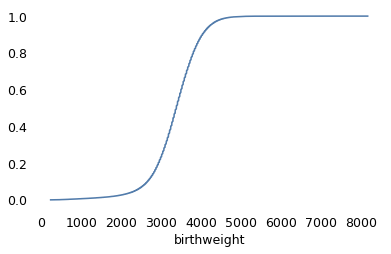

In [14]:
from empiricaldist import Cdf

vs1991["birthweight"] = vs1991["birthweight"].replace([7777, 9999], np.nan)
Cdf.from_seq(vs1991["birthweight"]).plot()

In [15]:
vs1991["birthweight"].nlargest(10)

1282965    8164.0
2328658    8164.0
2345800    8147.0
3078492    8108.0
1407733    7966.0
3037159    7965.0
2395933    7910.0
3046903    7890.0
2513239    7889.0
2582863    7880.0
Name: birthweight, dtype: float64

Flagging low birthweight babies.

In [16]:
vs1991["lbw"] = vs1991["birthweight"] < 2500

Dividing birthweights into bins.

In [17]:
bins = np.arange(1000, 5000, 250)
bins

array([1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500,
       3750, 4000, 4250, 4500, 4750])

In [18]:
vs1991["bin"] = pd.cut(vs1991["birthweight"], bins)
vs1991["bin"].value_counts().sort_index()

bin
(1000, 1250]     12374
(1250, 1500]     14661
(1500, 1750]     21393
(1750, 2000]     34816
(2000, 2250]     61218
(2250, 2500]    123119
(2500, 2750]    246404
(2750, 3000]    426903
(3000, 3250]    696739
(3250, 3500]    817652
(3500, 3750]    712945
(3750, 4000]    482449
(4000, 4250]    240867
(4250, 4500]    122762
(4500, 4750]     46395
Name: count, dtype: int64

Checking the codes for congenital birth defects.

In [19]:
vs1991["congenit"].value_counts()

congenit
2222222222222222222222    3556241
9999999999999999999999     498038
2222222222222222222221      23448
2222222222222222221222       5843
2222221222222222222222       3771
                           ...   
2222211112112122221222          1
2222121222122222222222          1
2212122222221221222222          1
2222222122222211222222          1
2222122222122222122222          1
Name: count, Length: 1008, dtype: int64

Each code is a vector that indicates the presence or absence of a particular condition. All 2's means no anomalies. 

In [20]:
vs1991["anomaly"] = vs1991["congenit"] != "2222222222222222222222"
vs1991["anomaly"].value_counts()

anomaly
False    3556241
True      559252
Name: count, dtype: int64

In [21]:
no_defect = vs1991["congenit"] == "2222222222222222222222"
no_defect.sum()

3556241

In [22]:
unknown = vs1991["congenit"] == "9999999999999999999999"
vs1991.loc[unknown, "anomaly"] = np.nan
unknown.sum()

/tmp/ipykernel_2292500/3685044362.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  vs1991.loc[unknown, "anomaly"] = np.nan


498038

In [23]:
known_defect = (~no_defect) & (~unknown)
known_defect.sum()

61214

If we select cases with known tobacco use and birthweight, we're down to about three million live births.

In [24]:
subset = vs1991.dropna(subset=["tobacco", "birthweight"])
subset.shape

(3001607, 9)

In [25]:
for name, group in subset.groupby("tobacco"):
    print(name, group["anomaly"].mean() * 1000)

N 18.1934659988842
Y 20.599922088040515


In [26]:
def percent_diff(x, rel):
    """Percentage difference.

    x: the number of interest
    rel: the number it is relative to

    returns: float percent
    """
    return (x - rel) / rel * 100

In [27]:
percent_diff(20.6, 18.2)

13.186813186813199

In [28]:
subset_no_defect = subset[subset["anomaly"] == 0]
subset_no_defect.shape

(2816996, 9)

In [29]:
weights = subset.groupby("tobacco")["birthweight"].mean()
weights

tobacco
N    3370.030102
Y    3145.189278
Name: birthweight, dtype: float64

In [30]:
percent_diff(3145, 3370)

-6.6765578635014835

In the 1991 data from NCHS, about 18% of the mothers reported smoking during pregnancy, down from 37% in Yerushalmy's dataset from the 1960s.
Babies of smokers were lighter on average than babies of nonsmokers by about 7%, which is comparable to the difference in the 1960s data.

The following figure shows the distribution of weights for the two groups. The vertical line is at 2500 grams, the threshold for low birthweight.

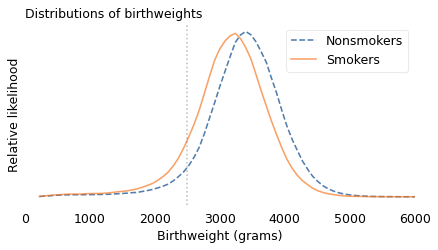

In [31]:
from utils import kdeplot

labels = {"Y": "Smokers", "N": "Nonsmokers"}
ls = {"Y": "-", "N": "--"}

xs = np.linspace(subset["birthweight"].min(), subset["birthweight"].max(), 101)
for name, group in subset.groupby("tobacco"):
    kdeplot(group["birthweight"], xs, label=labels[name], ls=ls[name])

plt.axvline(2500, color="gray", ls=":", alpha=0.5)
decorate(
    xlabel="Birthweight (grams)",
    ylabel="Relative likelihood",
    title="Distributions of birthweights",
    xlim=[0, 6000],
)

The shapes of the distributions are similar, but for smokers it is shifted to the left.
For mothers who smoked, the fraction of babies below 2500 grams is about 11%; for nonsmokers it is only 6%.

In [32]:
subset["lbw"].mean()

0.07262476400141657

In [33]:
for name, group in subset.groupby("tobacco"):
    lbw_rate = group["lbw"].mean()
    print(name, lbw_rate)

N 0.06365429478663773
Y 0.11421285960264155


In [34]:
percent_diff(11.4, 6.4)

78.125

In [35]:
(9793 * 11.1 + 3290 * 18.5) / (9793 + 3290)

12.960888175494917

In [36]:
subset["mort"].mean() * 1000

8.449473898481713

Overall infant mortality was substantially lower in 1991.
In the 1960s dataset, about 13 per 1000 babies died within the first *month* of life; in 1991, about 8.5 per 1000 died in the first *year*.

In 1991, the mortality rate was higher for babies of smokers, almost 12 per 1000, than babies of nonsmokers, 7.7 per 1000.
So the risk of mortality was 54% higher for babies of mothers who smoked.

In [37]:
for name, group in subset.groupby("tobacco"):
    rate = group["mort"].mean() * 1000
    print(name, rate)

N 7.71068917473998
Y 11.874562261649707


In [38]:
percent_diff(1187, 771)

53.95590142671855

In summary, babies of mothers who smoked were about twice as likely to be underweight, and underweight babies were about 50% more likely to die.
However, if we select babies lighter than 2500 grams, the mortality rate is 20% *lower* for babies of smokers, compared to LBW babies of nonsmokers.

In [39]:
for name, group in subset[subset["lbw"]].groupby("tobacco"):
    rate = group["mort"].mean() * 1000
    print(name, rate)

N 74.8512709572742
Y 60.138756452832666


In [40]:
percent_diff(60.1, 74.85)

-19.70607882431529

The analysis so far is based on only two groups, babies born lighter or heavier than 2500 grams.
But it might be a mistake to lump all LBW babies together.
In reality, a baby born close to 2500 grams has a better chance of surviving than a baby born at 1500 grams.

So, following the analysis in the 2006 paper, I partitioned the dataset into groups with similar birthweight and computed the mortality rate in each group.
The following figure shows the results.

In [41]:
table = pd.pivot_table(subset, index="bin", columns="tobacco", values="mort")
table *= 1000
table.index = bins[:-1] + np.diff(bins) / 2
table

tobacco,N,Y
1125.0,106.864725,102.376600
1375.0,72.467402,65.099458
1625.0,48.194837,43.963878
1875.0,32.530380,31.085935
2125.0,20.968439,22.160247
2375.0,13.399794,16.087278
2625.0,7.970344,9.483955
2875.0,4.987658,7.015749
3125.0,3.629459,5.610098
3375.0,2.534403,5.005695


In [42]:
def plot_table(table, title):
    table["Y"].plot(label="Smoker")
    table["N"].plot(ls="--", label="Nonsmoker")

    decorate(
        xlabel="Birth weight (grams)",
        ylabel="Mortality rate per 1000",
        title=title,
    )

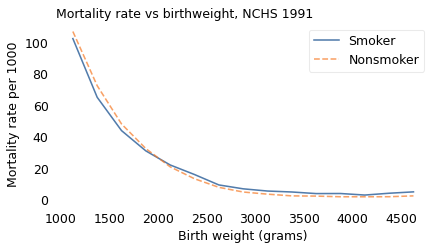

In [43]:
plot_table(table, "Mortality rate vs birthweight, NCHS 1991")

This figure provides a more detailed view of the Low Birthweight Paradox.
Among babies heavier than 2000 grams, mortality is higher for children of smokers, as expected.
Among lighter babies, mortality is lower for children of smokers.

## Other Groups

As it turns out, the Low Birthweight Paradox doesn't apply only to smokers and nonsmokers.
The 2006 paper describes a similar effect for babies born at high altitude: they are lighter on average than babies born at low altitude, but if we select LBW babies, the mortality rate is lower for the ones born at high altitude.

And Yerushalmy reported another example. 
Babies of short mothers are lighter, on average, than babies of tall mothers. In his dataset, babies of short mothers were twice as likely to be LBW, but among LBW babies of short mothers, the mortality rate was 49% lower and the rate of birth defects was 34% lower.

Yerushalmy called the relationship between smokers and nonsmokers, and between short and tall mothers, a "remarkable parallelism". 
But he did not recognize it as evidence that statistical bias is the explanation for both.
Instead, he doubled down:

> This comparison is presented not as proof that the differences between smokers and nonsmokers are necessarily of biological origin, rather it is to indicate that a biological hypothesis is not unreasonable.

With the benefit of further research, we can see that Yerushalmy was mistaken. Smoking, high altitude, and short mothers do not protect low-birthweight babies from birth defects and mortality. Rather, they provide a relatively benign explanation for low birthweight.

In [44]:
percent_diff(110, 214)

-48.598130841121495

In [45]:
percent_diff(96, 146)

-34.24657534246575

To see why, suppose four things can cause low birthweight:

* The mother might be short, which is not at all harmful to the baby.

* The baby might be born at high altitude, which has little if any effect on mortality.

* The mother might be a smoker, which is somewhat harmful to the baby, or

* The baby might have a birth defect, which greatly increases the rate of mortality.

Now suppose you are a doctor and you hear that a baby under your care was born underweight.
You would be concerned, because you know that the baby faces a higher than average risk of mortality.

But suppose the baby was born in Santa Fe, New Mexico, at 2200 meters of elevation to a mother at only 150 cm of elevation (just under five feet).
You would be relieved, because either of those factors might explain low birthweight, and neither implies a substantial increase in mortality.

And if you learned that the mother was a smoker, that would be good news, too, because it provides another possible explanation for low birthweight, which means that the last and most harmful explanation is less likely.
Maternal smoking is still bad for babies, but it is not as bad as birth defects.

It is frustrating that Yerushalmy did not discover this explanation.
In retrospect, he had all the evidence he needed, including the smoking gun (sorry!): the rates of birth defects.

We've seen that LBW babies of smokers are less likely to have birth defects, but that's not because maternal smoking somehow protects babies from congenital anomalies.
It's because low birthweight generally has a cause, and if the cause is not smoking, it is more likely to be something else, including a birth defect.

We can confirm that this explanation is correct by selecting babies with no congenital anomalies observed at birth.
If we do that, we find that babies of smokers have higher mortality rates in nearly every weight category, as expected.

In [46]:
lbw = (subset_no_defect["birthweight"] > 1000) & (
    subset_no_defect["birthweight"] < 2500
)

In [47]:
rate = subset_no_defect[lbw].groupby("tobacco")["mort"].mean() * 1000
rate

tobacco
N    19.730921
Y    21.316747
Name: mort, dtype: float64

In [48]:
percent_diff(*rate)

-7.4393451200994525

In [49]:
table = pd.pivot_table(subset_no_defect, index="bin", columns="tobacco", values="mort")
table *= 1000
table.index = bins[:-1] + np.diff(bins) / 2
table

tobacco,N,Y
1125.0,88.376720,90.295797
1375.0,54.970094,50.944947
1625.0,32.201915,30.974633
1875.0,21.577559,24.103738
2125.0,13.721836,17.170891
2375.0,8.864062,12.980332
2625.0,5.766043,8.139342
2875.0,3.911355,6.234500
3125.0,2.867080,5.139620
3375.0,2.117150,4.480155


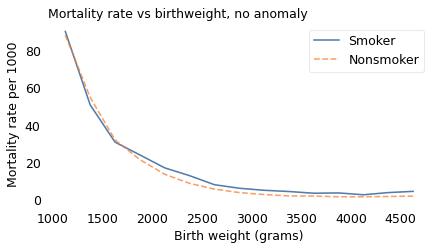

In [50]:
plot_table(table, "Mortality rate vs birthweight, no anomaly")

Maternal smoking might be less harmful than many birth defects, but to be clear, it is still harmful.
And Yerushalmy's error might be understandable, but it was also harmful.
At a time when the health risks of smoking were still contested, his paper created confusion and gave cover to people with an interest in minimizing the dangers.

## The End of the Paradox

When a paradoxical phenomenon is explained, it ceases to be a paradox. And in the case of the Low Birthweight Paradox, at about the same time it also ceased to be a phenomenon.

In the most recent NCHS dataset, including 3.8 million babies born in 2018, the Low Birthweight Paradox has disappeared.

In [51]:
vs2018 = pd.read_hdf("nchs.hdf", "vs2018")

In [52]:
vs2018.shape

(3801533, 3)

In [53]:
vs2018["yod"].value_counts(dropna=False)

yod
NaN       3780154
2018.0      18735
2019.0       2644
Name: count, dtype: int64

In [54]:
vs2018["mort"] = vs2018["yod"].notnull()
vs2018["mort"].value_counts()

mort
False    3780154
True       21379
Name: count, dtype: int64

In [55]:
vs2018["tobacco"].value_counts()

tobacco
N    3539051
Y     245360
U      17122
Name: count, dtype: int64

In [56]:
vs2018["tobacco"] = vs2018["tobacco"].replace(["U"], np.nan)
vs2018["tobacco"].value_counts(dropna=False)

tobacco
N      3539051
Y       245360
NaN      17122
Name: count, dtype: int64

In [57]:
from empiricaldist import Pmf

Pmf.from_seq(vs2018["tobacco"])

,probs
tobacco,
N,0.935166
Y,0.064834


In this dataset, only 6% of the mothers reported smoking during pregnancy, down from 18% in 1991 and 37% in the 1960s.

In [58]:
vs2018["birthweight"].value_counts().sort_index()

birthweight
227      157
228        5
229        7
230       34
231        4
        ... 
8025       1
8160       1
8161       1
8165      12
9999    2100
Name: count, Length: 5357, dtype: int64

<Axes: xlabel='birthweight'>

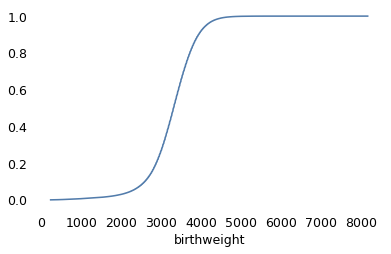

In [59]:
vs2018["birthweight"] = vs2018["birthweight"].replace([7777, 8165, 9999], np.nan)
Cdf.from_seq(vs2018["birthweight"]).plot()

In [60]:
vs2018["birthweight"].nlargest(10)

2960521    8161.0
2599521    8160.0
1781210    8025.0
3162300    7975.0
1691806    7940.0
3218818    7940.0
2001264    7875.0
3185226    7860.0
1877614    7853.0
2902164    7815.0
Name: birthweight, dtype: float64

In [61]:
vs2018["lbw"] = vs2018["birthweight"] < 2500

In [62]:
bins = np.arange(1000, 5000, 250)
bins

array([1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500,
       3750, 4000, 4250, 4500, 4750])

In [63]:
vs2018["bin"] = pd.cut(vs2018["birthweight"], bins)
vs2018["bin"].value_counts().sort_index()

bin
(1000, 1250]     12263
(1250, 1500]     15841
(1500, 1750]     23552
(1750, 2000]     38581
(2000, 2250]     69739
(2250, 2500]    132815
(2500, 2750]    258005
(2750, 3000]    460541
(3000, 3250]    702121
(3250, 3500]    772754
(3500, 3750]    617937
(3750, 4000]    379535
(4000, 4250]    176360
(4250, 4500]     75196
(4500, 4750]     26293
Name: count, dtype: int64

In [64]:
subset = vs2018.dropna(subset=["tobacco", "birthweight"])
subset.shape

(3782433, 6)

In [65]:
weights = subset.groupby("tobacco")["birthweight"].mean()
weights

tobacco
N    3275.077779
Y    3067.694444
Name: birthweight, dtype: float64

In [66]:
percent_diff(3067, 3275)

-6.35114503816794

Babies of smokers were lighter on average than babies of nonsmokers by about 6%, comparable to the difference in the previous two datasets.

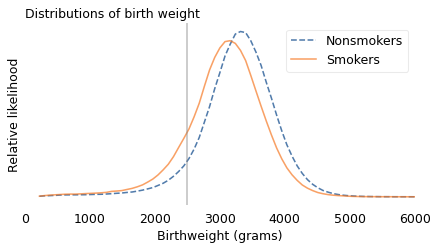

In [67]:
labels = {"Y": "Smokers", "N": "Nonsmokers"}
ls = {"Y": "-", "N": "--"}

xs = np.linspace(subset["birthweight"].min(), subset["birthweight"].max(), 101)
for name, group in subset.groupby("tobacco"):
    kdeplot(group["birthweight"], xs, label=labels[name], ls=ls[name])

plt.axvline(2500, color="gray", alpha=0.5)
decorate(
    xlabel="Birthweight (grams)",
    ylabel="Relative likelihood",
    title="Distributions of birth weight",
    xlim=[0, 6000],
)

In [68]:
subset["lbw"].mean()

0.08271157744234994

In [69]:
for name, group in subset.groupby("tobacco"):
    lbw_rate = group["lbw"].mean()
    print(name, lbw_rate)

N 0.07847403941187513
Y 0.1438352533387705


In [70]:
percent_diff(14.38, 7.84)

83.4183673469388

In 2018, fewer babies died in the first year of life;
the mortality rate was 5.5 per 1000, down from 8.5 in 1991.
And the mortality rate for babies of smokers was more than twice the rate for babies of nonsmokers, almost 11 per 1000 compared to 5.1.

In [71]:
subset["mort"].mean() * 1000

5.5213139267767595

In [72]:
for name, group in subset.groupby("tobacco"):
    rate = group["mort"].mean() * 1000
    print(name, rate)

N 5.16056731750013
Y 10.724844530533185


In [73]:
percent_diff(10.72, 5.16)

107.75193798449614

In [74]:
for name, group in subset[subset["lbw"]].groupby("tobacco"):
    rate = group["mort"].mean() * 1000
    print(name, rate)

N 45.07905857431578
Y 43.20707643456566


In [75]:
percent_diff(60.1, 74.85)

-19.70607882431529

Again, we can partition the dataset into groups with similar birthweight and compute the mortality rate in each group.
The following figure shows the results.

In [76]:
table = pd.pivot_table(subset, index="bin", columns="tobacco", values="mort")
table *= 1000
table.index = bins[:-1] + np.diff(bins) / 2
table

tobacco,N,Y
1125.0,59.384364,67.014795
1375.0,40.366712,46.951220
1625.0,31.345859,36.663981
1875.0,19.119896,25.081282
2125.0,12.202122,16.664654
2375.0,6.994627,12.336111
2625.0,3.954523,9.317009
2875.0,2.652722,6.695117
3125.0,1.772246,4.676507
3375.0,1.385945,4.235809


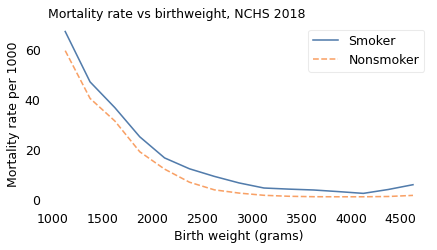

In [77]:
plot_table(table, "Mortality rate vs birthweight, NCHS 2018")

At every birthweight, mortality is higher for children of smokers.
For better or worse, the low birthweight paradox is no more.

## A Twin Paradox

The Low Birthweight Paradox might seem like an esoteric issue, but similar phenomena are an ongoing source of confusion.
As an example, in 2000, researchers at the University of Hong Kong reported a study of 1.5 million babies born in Sweden between 1982 and 1995.
They computed mortality rates for single births, twins, and triplets as a function of gestational age (that is, number of weeks of pregnancy), and found:

* Twins and triplets are more likely to be born pre-term, that is, prior to 37 weeks of gestational age,

* Babies born pre-term have higher mortality rates than babies born full-term, and

* Overall mortality rates are higher for twins and triplets.

These results were unsurprising. However, when they selected babies born pre-term, they found that survival rates were higher for twins and triplets, compared to single births.

To explain this surprising result, they suggest "twins have better health than singletons initially", that is, before 36 weeks of gestation, but that "they could not enjoy the benefit of a longer gestational duration as much as singletons could."
That is, they suggested a biological explanation, not a statistical one.

In an invited commentary on their paper, medical statistician Rolv Lie reports similar results from 1.8 million babies born in Norway between 1967 and 1998.
However, he comes to a different conclusion, one which I hope has occurred to you after reading this far.

He suggests that the difference in mortality between single and multiple births "does not reflect the frailty among undelivered fetuses at the same gestational ages."
Rather, "Preterm babies have more than the prematurity problem of their specific gestational age, for they also suffer from the pathological causes of their preterm delivery, which are usually unknown."

In less flowery language, multiple pregnancy is one of several things that can cause preterm birth, and among them, it is relatively harmless.
So if a preterm baby is a twin or triplet, it is less likely that they suffer from some other, more harmful, condition.

## The Obesity Paradox

The Low Birthweight Paradox is no more, and the Twin Paradox has been explained, but the Obesity Paradox is alive and well.

The first example of the Obesity Paradox was reported in 1999.
Although it was well known that obesity is a risk factor for kidney disease, and that kidney disease is often fatal, researchers found that among patients undergoing dialysis due to kidney failure, survival times for obese patients were *longer* than for other patients.
They suggested as a possible explanation: "Overweight patients have an increase in adipose tissue and, therefore, are less likely to suffer from energy deficits."
Based on this conclusion, they recommended that "proper nutrition to maintain a high-end normal BMI [body mass index] should help reduce the high mortality and morbidity rates" in patients on dialysis.

Since then, similar patterns have been reported for *many* other diseases.
Among them:

* Obesity increases the risk of stroke, myocardial infarction, heart failure, and diabetes.

* All of these conditions are associated with increased mortality and morbidity.

* Nevertheless, if we select patients with any of these conditions, we find that obese patients have *lower* mortality and morbidity than normal-weight patients.

To get a sense of the confusion these results have created, you only have to read the titles of the papers written about them.
Here's a sample from a quick search:

* 2006: "The Obesity Paradox: Fact or Fiction?"

* 2007: "Obesity-survival paradox-still a controversy?"

* 2010: "The obesity paradox: perception vs knowledge"

* 2011: "Effect of body mass index on outcomes after cardiac surgery: is there an obesity paradox?"

* 2013: "Obesity Paradox Does Exist"

* 2019: "Obesity paradox in cardiovascular disease: where do we stand?"

So, where *do* we stand?

In my opinion, the most likely explanation is the one offered in a letter to the editor of *Epidemiology* with the promising title, "The 'Obesity Paradox' Explained".
As an example, the authors consider the obesity paradox in patients with heart failure, and propose the following explanation:

* Obesity is one cause of heart failure, and heart failure causes mortality.

* But there are other causes of heart failure, which also cause mortality.

* Compared to other causes, obesity is relatively benign.

* If a patient with heart failure is obese, the other causes are less likely.

* Therefore, among patients with heart failure, obese patients have lower mortality.

Using data from the National Health and Nutrition Examination Survey and the National Death Index, they show that this explanation is plausible; that is, the statistical relationships implied by their theory appear in the data, and they are strong enough to explain the Obesity Paradox even if obesity has no protective effect.

I think their argument is convincing, but it does not rule out other causal mechanisms; for example, in the case of kidney failure, fat tissue might prevent organ damage by diluting the toxins that accumulate when kidney function is diminished.
And it does not rule out other statistical explanations; for example, if long-term severe disease causes weight loss, obesity might be an indicator of relatively short-term mild disease.

Nevertheless, until there is evidence for other explanations, the title of my article is "The Obesity Paradox: No."

## Berkson's Toaster

At some point while you were reading this chapter, you might have noticed connections between the Low Birthweight Paradox and Berkson's Paradox.

With Berkson's paradox, if there are two ways to be included in a sample, we often find that the alternatives are negatively correlated in the sample, even if they are unrelated, or positively correlated, in the general population.
For example, to dunk a basketball, you have to be tall or you have to be able to jump.
If we sample people who can dunk, we find that the shorter people can jump higher, even if there is no such relationship in general.

With the Low Birthweight Paradox, again, there are two causes for the same effect; if we select for the effect, we often find that the alternatives are negatively correlated in the sample.
And if one of the causes is more harmful, the other might seem relatively benign.
For example, if jumping is bad for your knees, we might find that, among people who can dunk, taller players have healthier knees. (I think I just invented a new paradox.)

When you think of the Low Birthweight Paradox, and the related paradoxes in this chapter, I suggest you remember what I call "Berkson's toaster".

Suppose you hear a smoke alarm in your kitchen.
You get up and move quickly to the kitchen, where you find that someone has left a piece of toast in the toaster too long.
You would probably feel relieved.

Why? Because of all the things that could cause a smoke alarm, burnt toast is probably the least harmful.
That doesn't mean burning toast is good, but if the alarm is sounding, burnt toast is better than the alternatives.

## Causal diagrams

The 2006 paper explaining the Low Birthweight Paradox and the 2013 paper explaining the Obesity Paradox are noteworthy because they use causal diagrams to represent hypothetical causes and their effects.
For example, here is a causal diagram that represents an explanation for the Low Birthweight Paradox:

In [78]:
# based on https://matplotlib.org/matplotblog/posts/mpl-for-making-diagrams/


def make_diagram(fig_width=6, fig_height=2, bg_color="white"):
    fig = plt.figure(figsize=(fig_width, fig_height))
    ax = fig.add_axes((0, 0, 1, 1))
    ax.set_xlim(0, fig_width)
    ax.set_ylim(0, fig_height)
    ax.set_facecolor(bg_color)

    ax.tick_params(bottom=False, top=False, left=False, right=False)
    ax.tick_params(labelbottom=False, labeltop=False, labelleft=False, labelright=False)

    return fig, ax

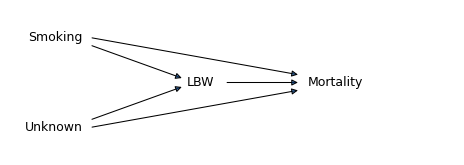

In [79]:
fig, ax = make_diagram()

# add rectangle to plot
# ax.add_patch(Rectangle((1, 1), 2, 1))

options = dict(fontsize=12, va="center")
y = 1
plt.text(1, y + 0.6, "Smoking", ha="right", **options)
plt.text(1, y - 0.6, "Unknown", ha="right", **options)
plt.text(2.75, y, "LBW", ha="right", **options)
plt.text(4, y, "Mortality", ha="left", **options)

arrowprops = dict(arrowstyle="<|-")
plt.annotate("", [1.1, y + 0.5], [2.35, y + 0.05], arrowprops=arrowprops)
plt.annotate("", [1.1, y - 0.5], [2.35, y - 0.05], arrowprops=arrowprops)
plt.annotate("", [2.9, y], [3.9, y], arrowprops=arrowprops)
plt.annotate("", [1.1, y + 0.6], [3.9, y + 0.1], arrowprops=arrowprops)
plt.annotate("", [1.1, y - 0.6], [3.9, y - 0.1], arrowprops=arrowprops)
plt.savefig("birthweight1.png", dpi=300)

Each arrow represents a causal relationship, so this diagram represents the following hypotheses:

* Maternal smoking causes low birthweight (LBW) and mortality, in the sense that it increases the probability of both.

* Additional unknown factors, including birth defects, also cause both LBW and mortality.

* LBW also causes mortality (regardless of what caused it).

Importantly, these arrows represent truly causal relationships, not just statistical association.
For example, the arrow from LBW to mortality means that low birthweight is harmful in and of itself, not only because it is statistical evidence of a harmful condition.
And there is no arrow from mortality to LBW because, even though they are correlated, mortality does not cause low birthweight.

However, this diagram does not contain all of the information we need to explain the Low Birthweight Paradox, because it does not represent the strengths of the different causal relationships.
In order to explain the paradox, the total contribution of the unknown factors (U) to mortality has to exceed the total contribution of maternal smoking.
Also, this diagram is not the only one that could explain the Low Birthweight Paradox.
For example, the arrow from LBW to mortality is not necessary; the paradox could happen even if low birthweight were entirely harmless.
Nevertheless, diagrams like this are a useful way to document a hypothetical set of causal relationships.

The following causal diagram represents the explanation of the Obesity Paradox proposed in the 2013 paper:

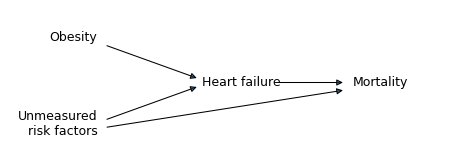

In [80]:
fig, ax = make_diagram()

options = dict(fontsize=12, va="center")
y = 1
plt.text(1.2, y + 0.6, "Obesity", ha="right", **options)
plt.text(1.2, y - 0.55, "Unmeasured\nrisk factors", ha="right", **options)
plt.text(2.6, y, "Heart failure", ha="left", **options)
plt.text(4.6, y, "Mortality", ha="left", **options)

arrowprops = dict(arrowstyle="<|-")
plt.annotate("", [1.3, y + 0.5], [2.55, y + 0.05], arrowprops=arrowprops)
plt.annotate("", [1.3, y - 0.5], [2.55, y - 0.05], arrowprops=arrowprops)
plt.annotate("", [3.6, y], [4.5, y], arrowprops=arrowprops)
plt.annotate("", [1.3, y - 0.6], [4.5, y - 0.1], arrowprops=arrowprops)
plt.savefig("birthweight2.png", dpi=300)

The arrows in this diagram represent the following hypotheses:

* Obesity causes heart failure, in the sense that it increases its probability.

* Other risk factors, including "genetic factors and lifestyle behaviors" cause both heart failure and mortality.

* Heart failure causes mortality.

In this model, obesity causes mortality indirectly, by increasing the probability of heart failure, but it is not a direct cause of mortality.
This assumption implies that an obese patient who does not have heart failure would not have increased mortality.
In reality, that's probably not true; for example, obesity also causes diabetes, which increases mortality.
But we can leave that out of the model because it is not necessary to explain the paradox.
What is necessary, but not shown in the diagram, is that the total contribution of the unknown factors to mortality must exceed the contribution of obesity indirectly through heart failure.

Comparing these two diagrams, we can see what the two paradoxes have in common:

* In the Low Birthweight Paradox, the condition we selected has two causes, maternal smoking and other factors like birth defects.

* In the Obesity Paradox, the condition we selected has two causes, obesity and other genetic and lifestyle factors.

Likewise, when we select babies born preterm, that condition has two causes, multiple birth and other risk factors.

In the context of causal modeling, a condition that has two (or more) causes is called a "collider", because in the causal diagram, the incoming arrows collide.
So what I've been calling Berkson's Paradox is more generally known as collider bias.

## Sources and related reading

* Yerushalmy's paper was originally published in the *[American Journal of Epidemiology](https://academic.oup.com/aje)* in 1971 and reprinted in the *[International Journal of Epidemiology](https://academic.oup.com/ije/article/43/5/1355/2904402)* in 2014.

* The editorial introduction to the reprinted version is by Shah Ebrahim, with commentaries by Keyes, Davey Smith, and Susser, Parascandola, Goldstein, Kramer, Zhang, and Platt, and VanderWeele.

* The paper that demonstrated the low birthweight paradox with a computer simulation is by Allen Wilcox and Ian Russell (1983).

* The paper that demonstrated it with NCHS data is by Hernández-Díaz, Schisterman, and Hernán (2006).

* The NCHS data is available from the [Centers for Disease Control and Prevention (CDC)](https://www.cdc.gov/nchs/data_access/vitalstatsonline.htm).

* The paper reporting the Twin Paradox is by Cheung, Yip, and Karlberg (2000); the commentary explaining it is by Rolv Lie (2000).

* The paper reporting the Obesity Paradox is by Fleischmann, Teal, Dudley, May, Bower, and Salahudeen (1999); the 2013 paper explaining it is by Banack and Kaufman.

* If you would like to read more about causal modeling, a good introduction for a general audience is Judea Pearl's book, "[The book of why: the new science of cause and effect](https://www.basicbooks.com/titles/judea-pearl/the-book-of-why/9780465097609/)" (Basic Books, 2018).